In [ ]:
!pip install ultralytics
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 141.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
import shutil
from roboflow import Roboflow

In [ ]:
roboflow_api_key = "FpdHSnr4zKdtmC49Nhbp"
rf = Roboflow(api_key=roboflow_api_key )
project = rf.workspace("workspace-5ujvu").project("basketball-players-fy4c2-vfsuv")
version = project.version(17)
dataset = version.download("yolov5")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Basketball-Players-17 in yolov5pytorch:: 100%|██████████| 652/652 [00:00<00:00, 6793.29it/s]


In [ ]:


shutil.move("Basketball-Players-17/train",
"Basketball-Players-17/Basketball-Players-17/train",
)
shutil.move("Basketball-Players-17/valid",
"Basketball-Players-17/Basketball-Players-17/valid",
)
shutil.move("Basketball-Players-17/test",
"Basketball-Players-17/Basketball-Players-17/test",
)

'Basketball-Players-17/Basketball-Players-17/test'

In [ ]:
!yolo task=detect mode=train model=yolov5l6u.p data={dataset.location}/data.yaml epochs=250 imgsz=640

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.69 🚀 Python-3.11.11 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=best.pt, data=/content/Basketball-Players-17/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ball_detector_model.pt to ball_detector_model.pt


In [ ]:
from ultralytics import YOLO
trained_model = list(uploaded.keys())[0]
model = YOLO(trained_model)

In [ ]:
import yaml

with open("Basketball-Players-17/data.yaml", "r") as f:
    data = yaml.safe_load(f)

data['test'] = "/content/Basketball-Players-17/Basketball-Players-17/test/images"

with open("Basketball-Players-17/data.yaml", "w") as f:
    yaml.dump(data, f)

metrics = model.val(data="Basketball-Players-17/data.yaml", split="test")

print("mAP50:     ", metrics.box.map50)
print("mAP50-95:  ", metrics.box.map)
print("Precision: ", metrics.box.mp)
print("Recall:    ", metrics.box.mr)

from IPython.display import Image, display
import glob

for img_path in sorted(glob.glob("runs/detect/val/*.png")):
    print(img_path)
    display(Image(filename=img_path))

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1402.1±913.3 MB/s, size: 74.1 KB)
val: Scanning /content/Basketball-Players-17/Basketball-Players-17/test/labels... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 201.6it/s 0.2s
val: New cache created: /content/Basketball-Players-17/Basketball-Players-17/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4s/it 2.9s
                   all         32        471      0.897      0.934      0.937      0.728
                  Ball         24         24      0.643       0.75      0.738      0.359
                 Clock         22         37      0.999          1      0.995      0.817
                  Hoop         25         25      0.982          1      0.995      0.799
               Overlay         28         36      0.774          1      0.985       0.81
          

runs/detect/val2/BoxF1_curve.png


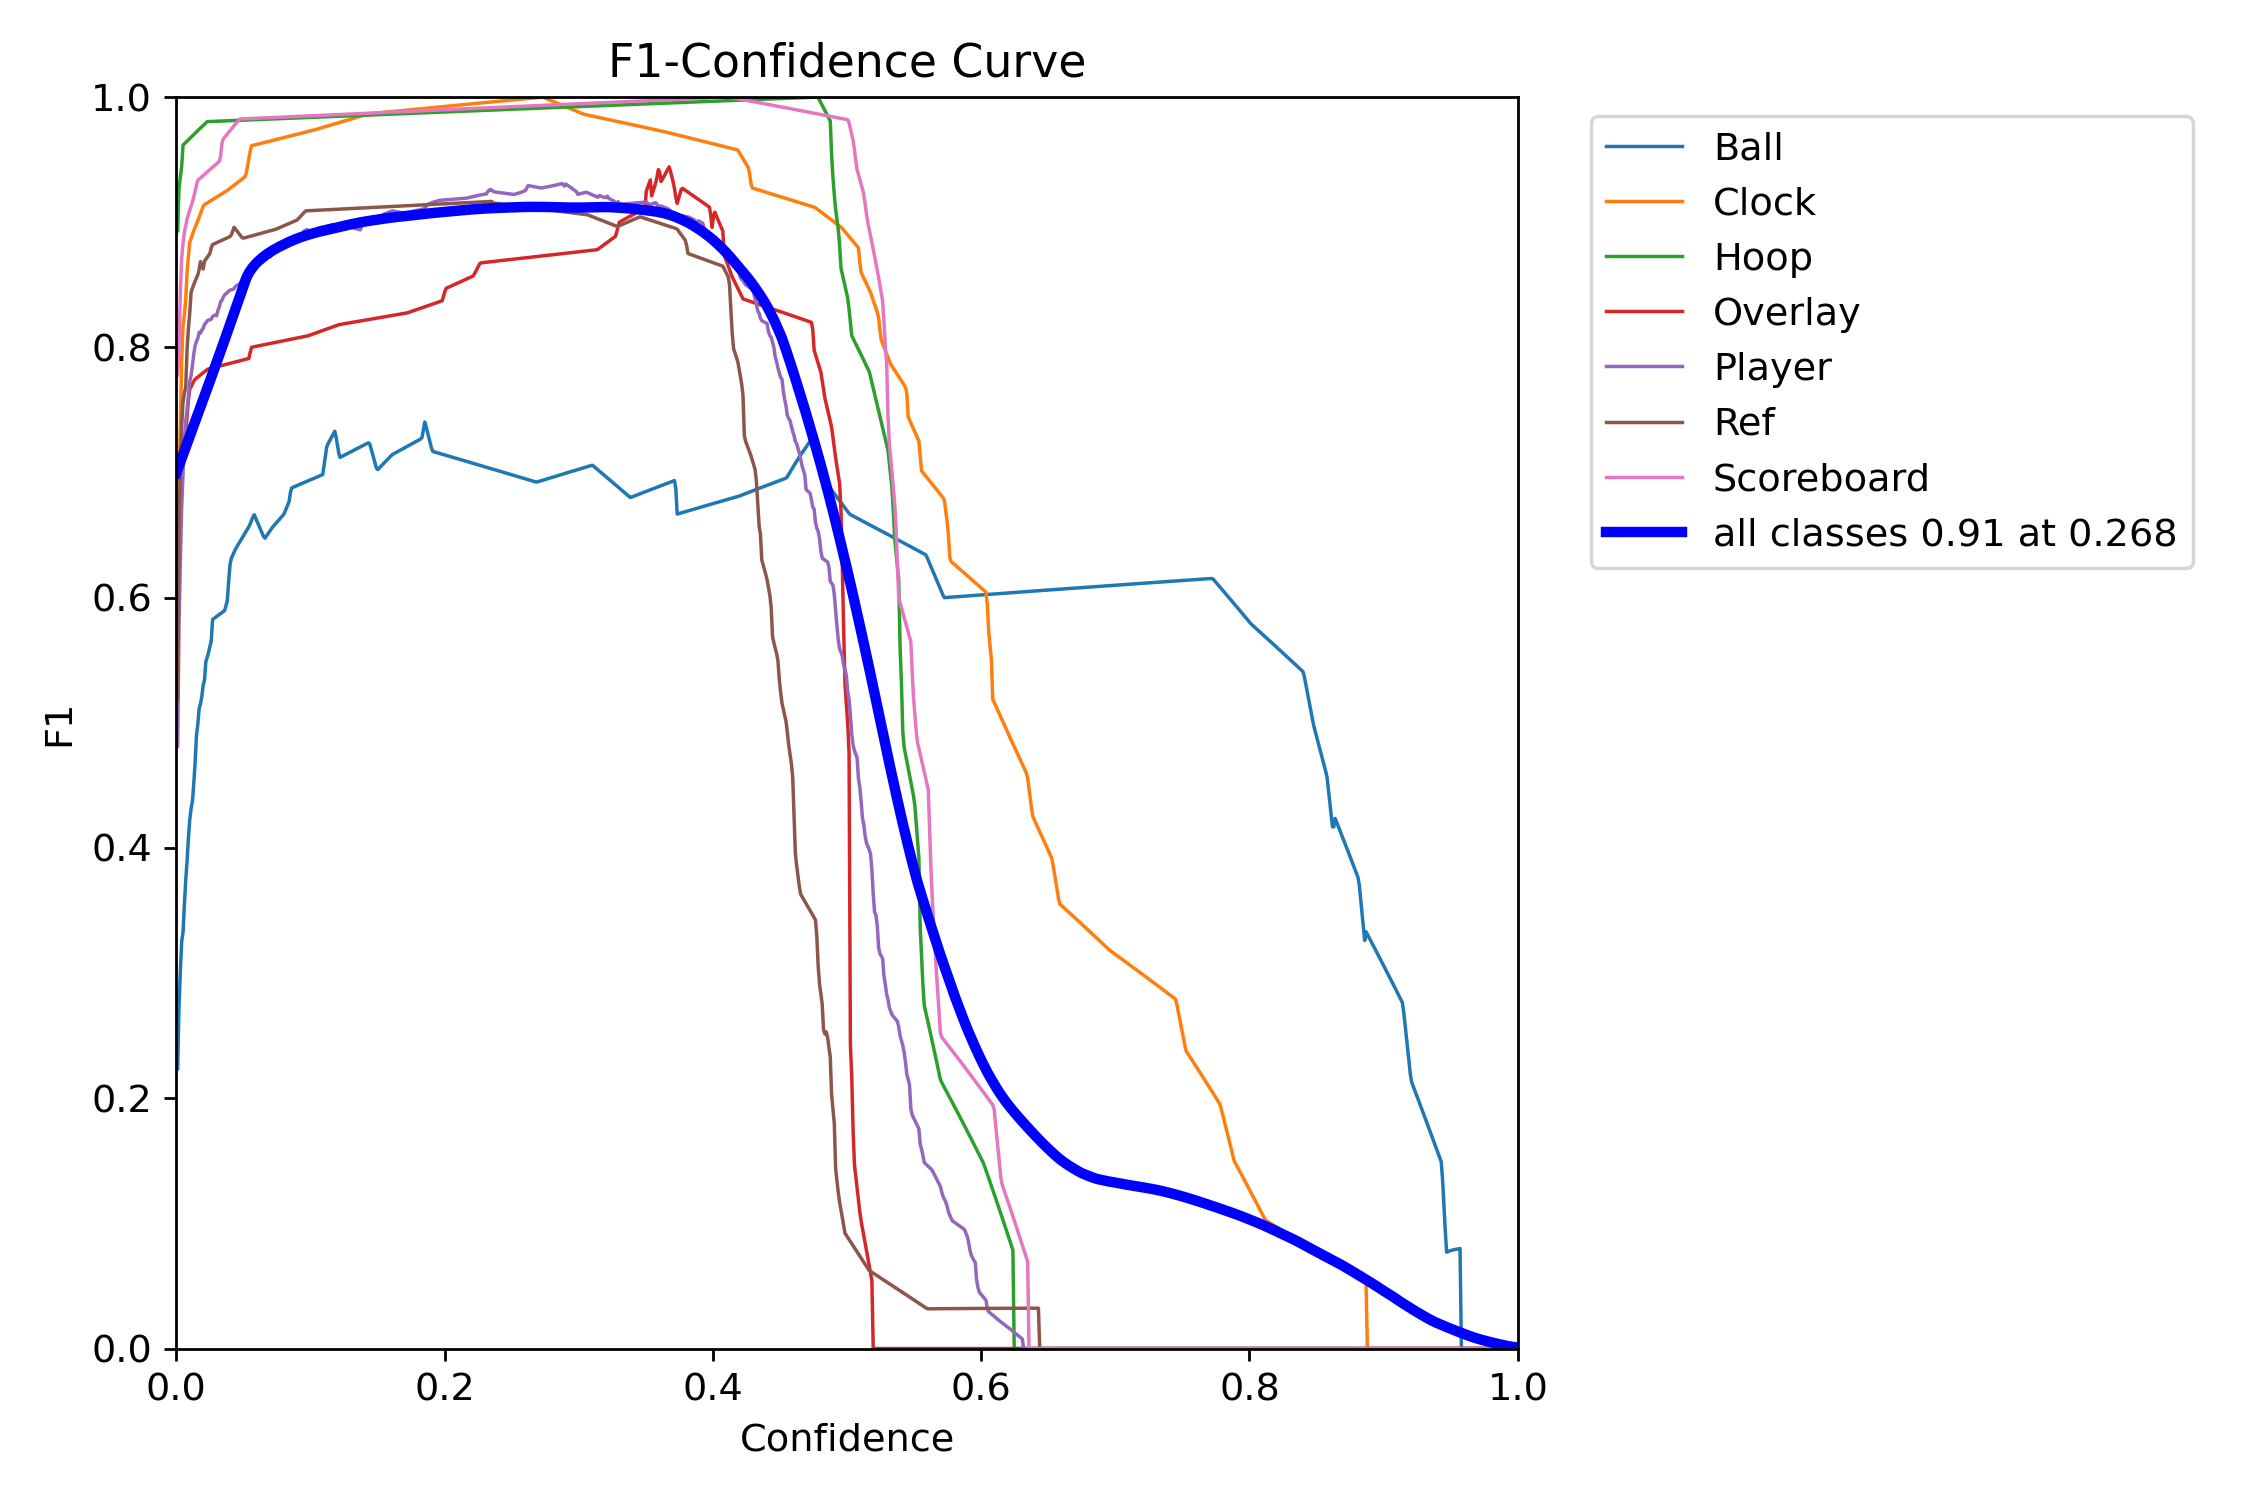

runs/detect/val2/BoxPR_curve.png


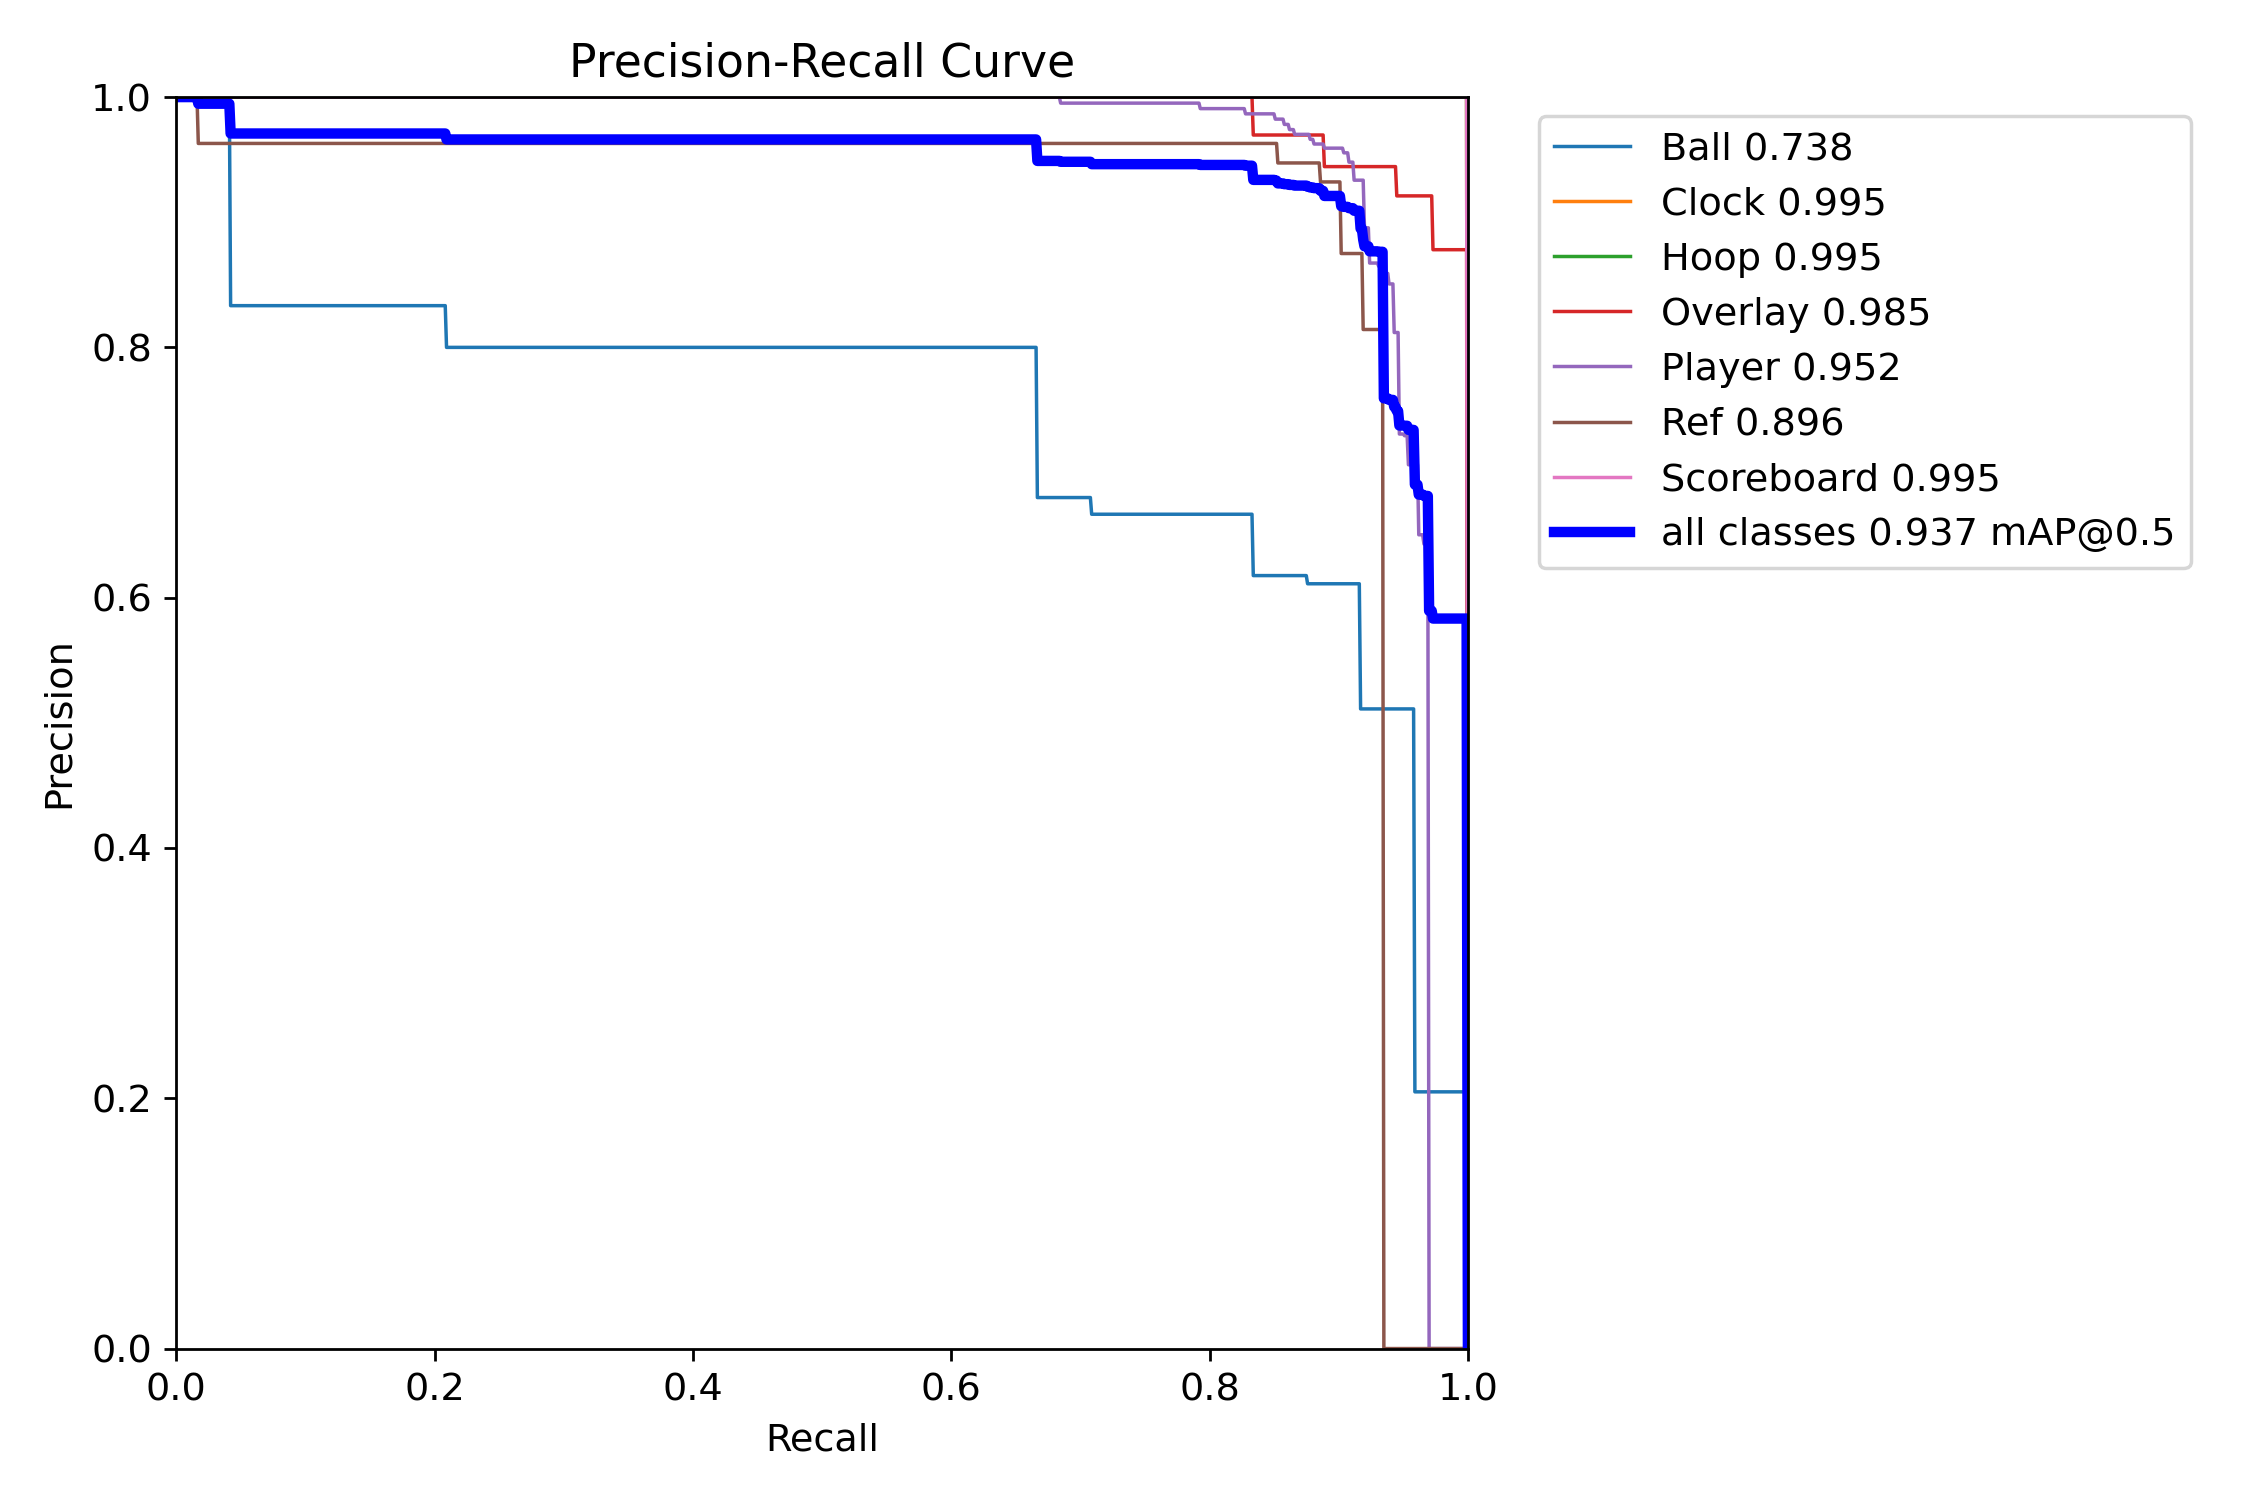

runs/detect/val2/BoxP_curve.png


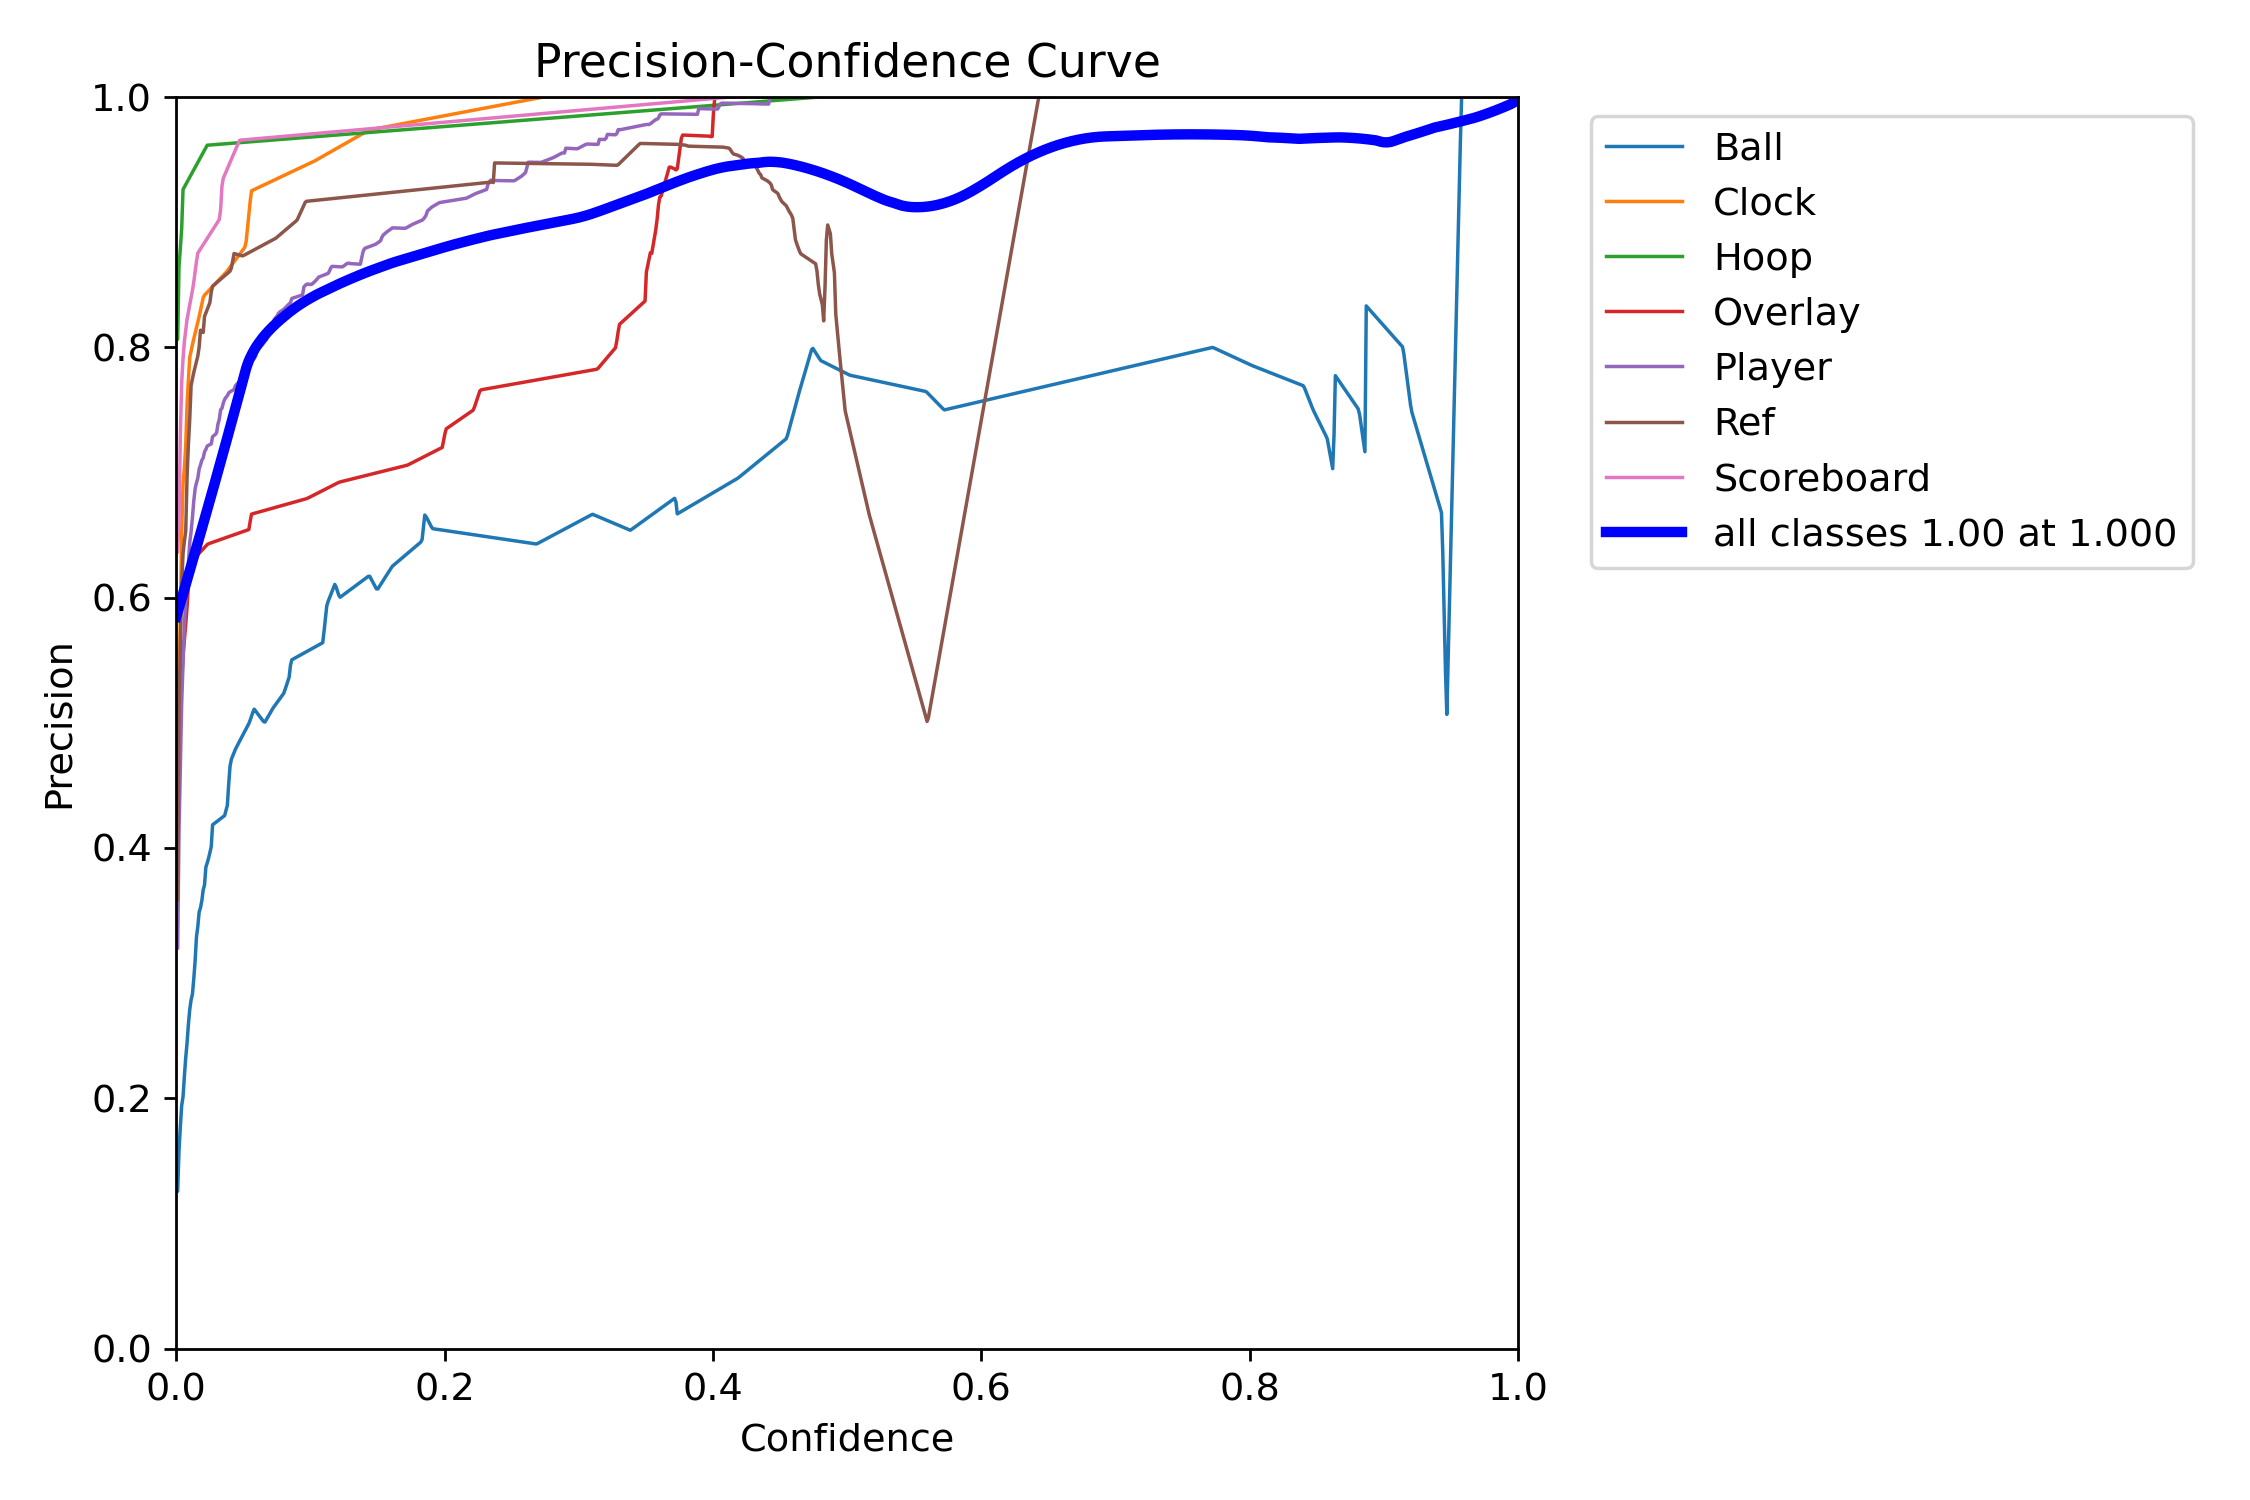

runs/detect/val2/BoxR_curve.png


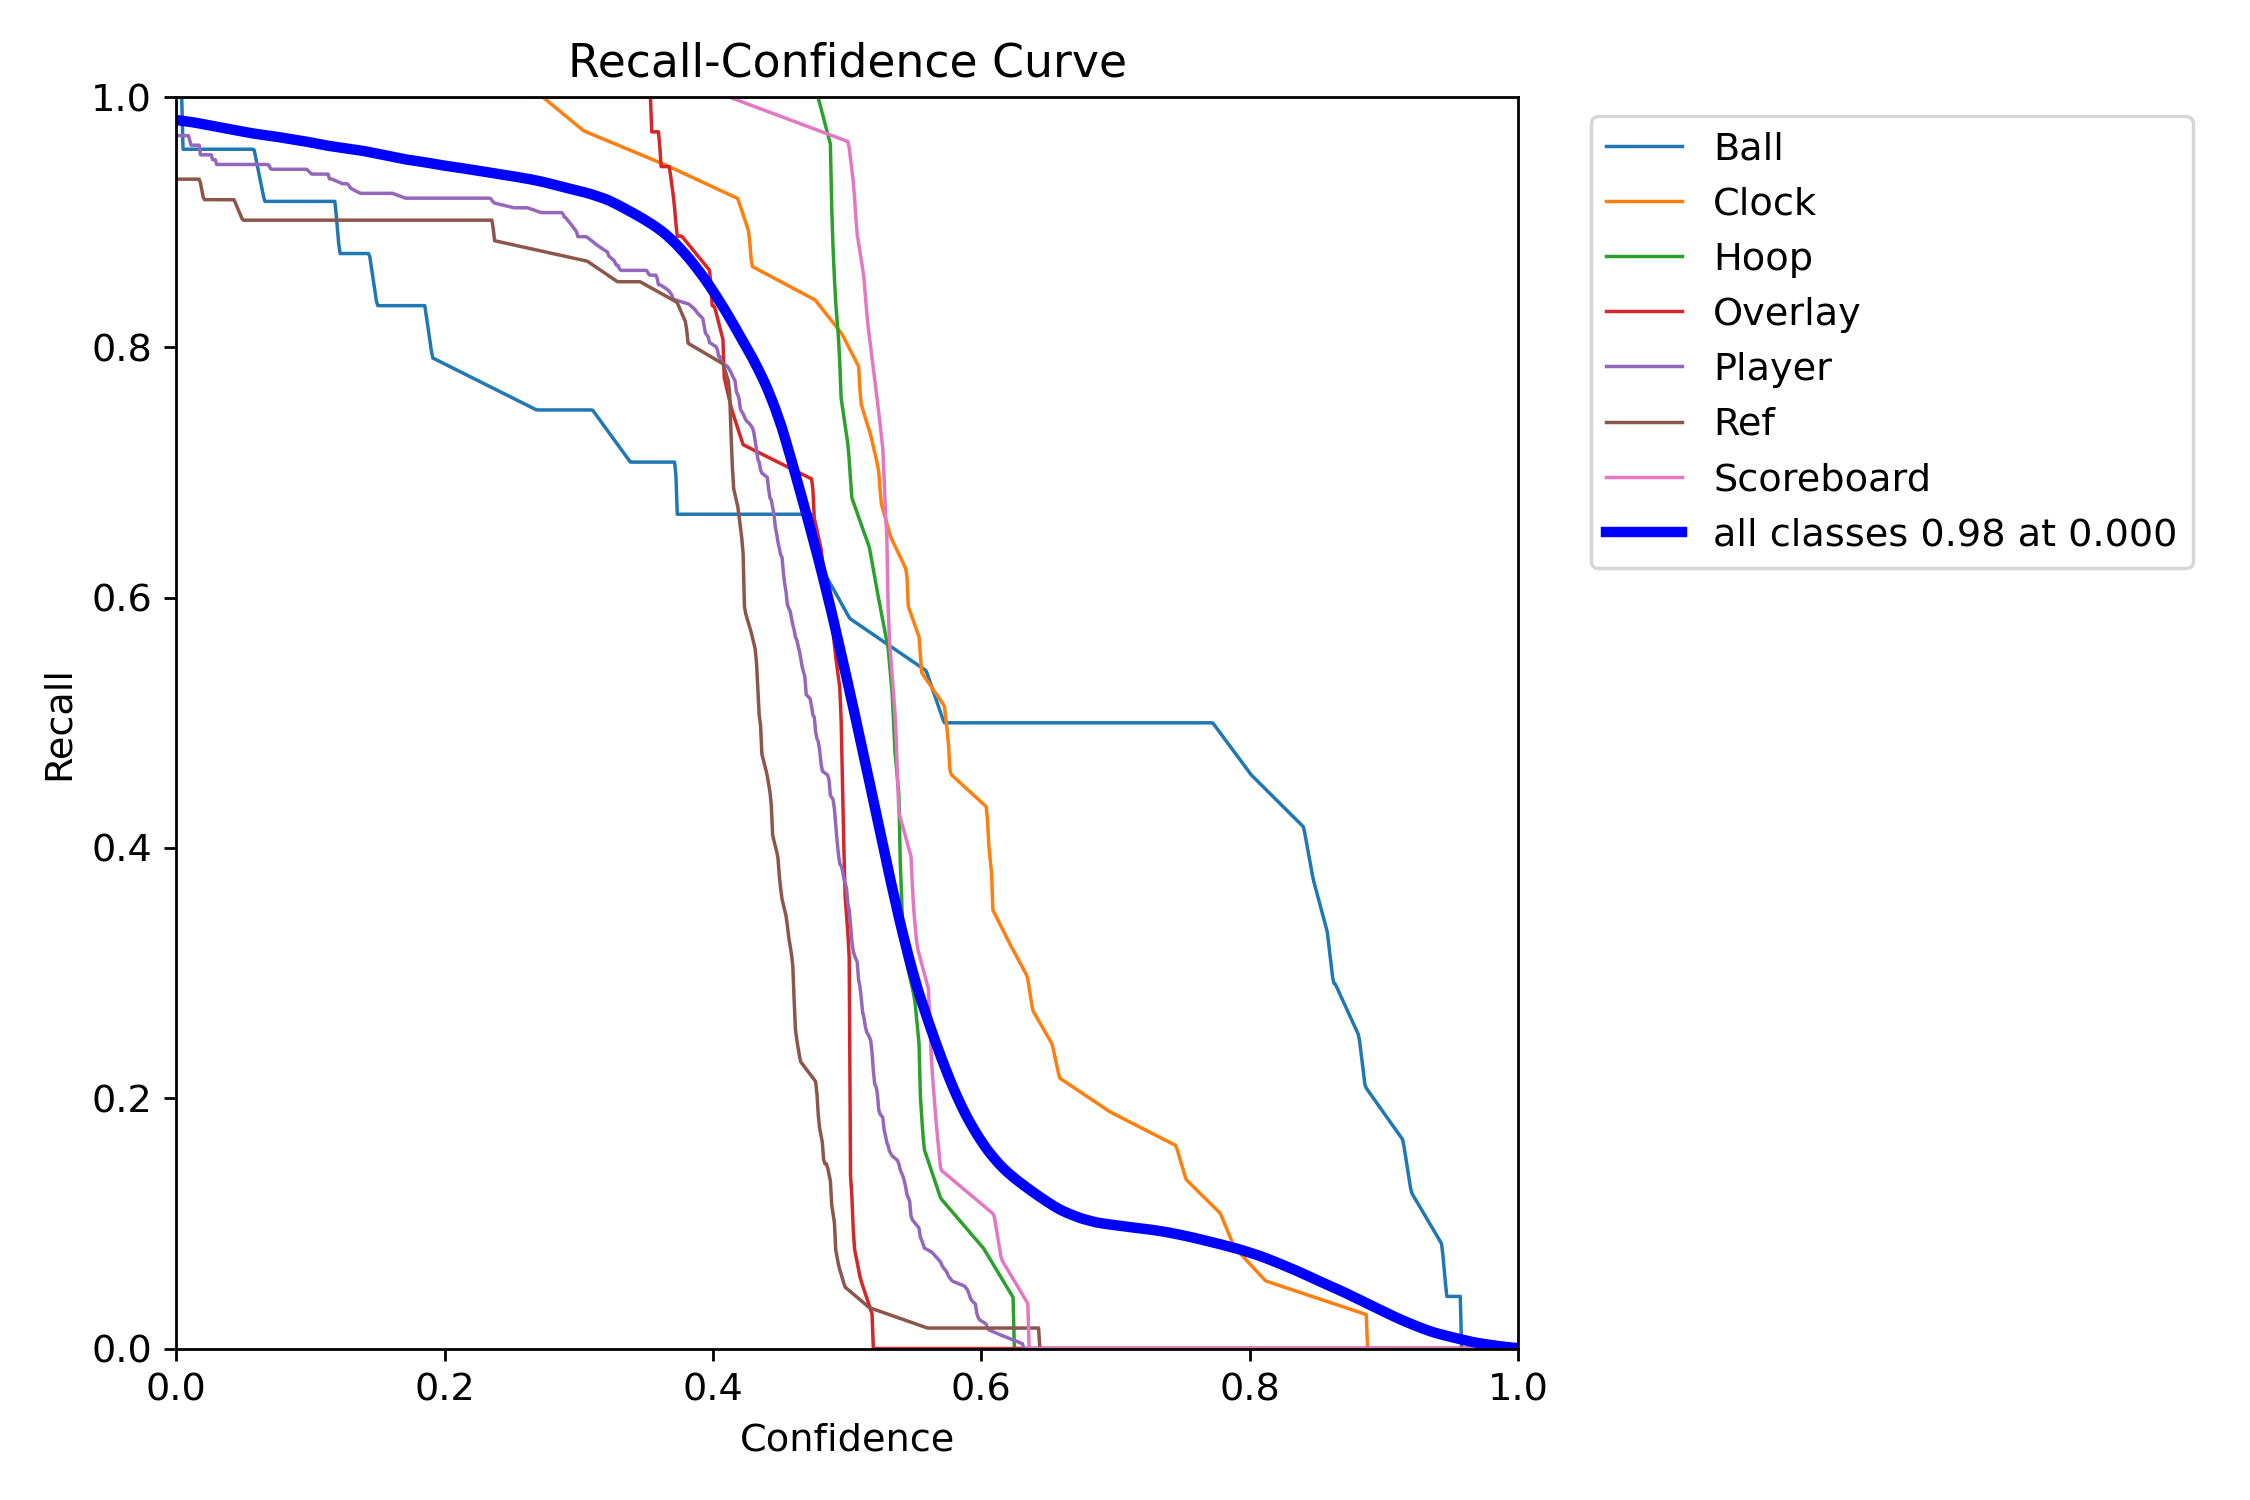

runs/detect/val2/confusion_matrix.png


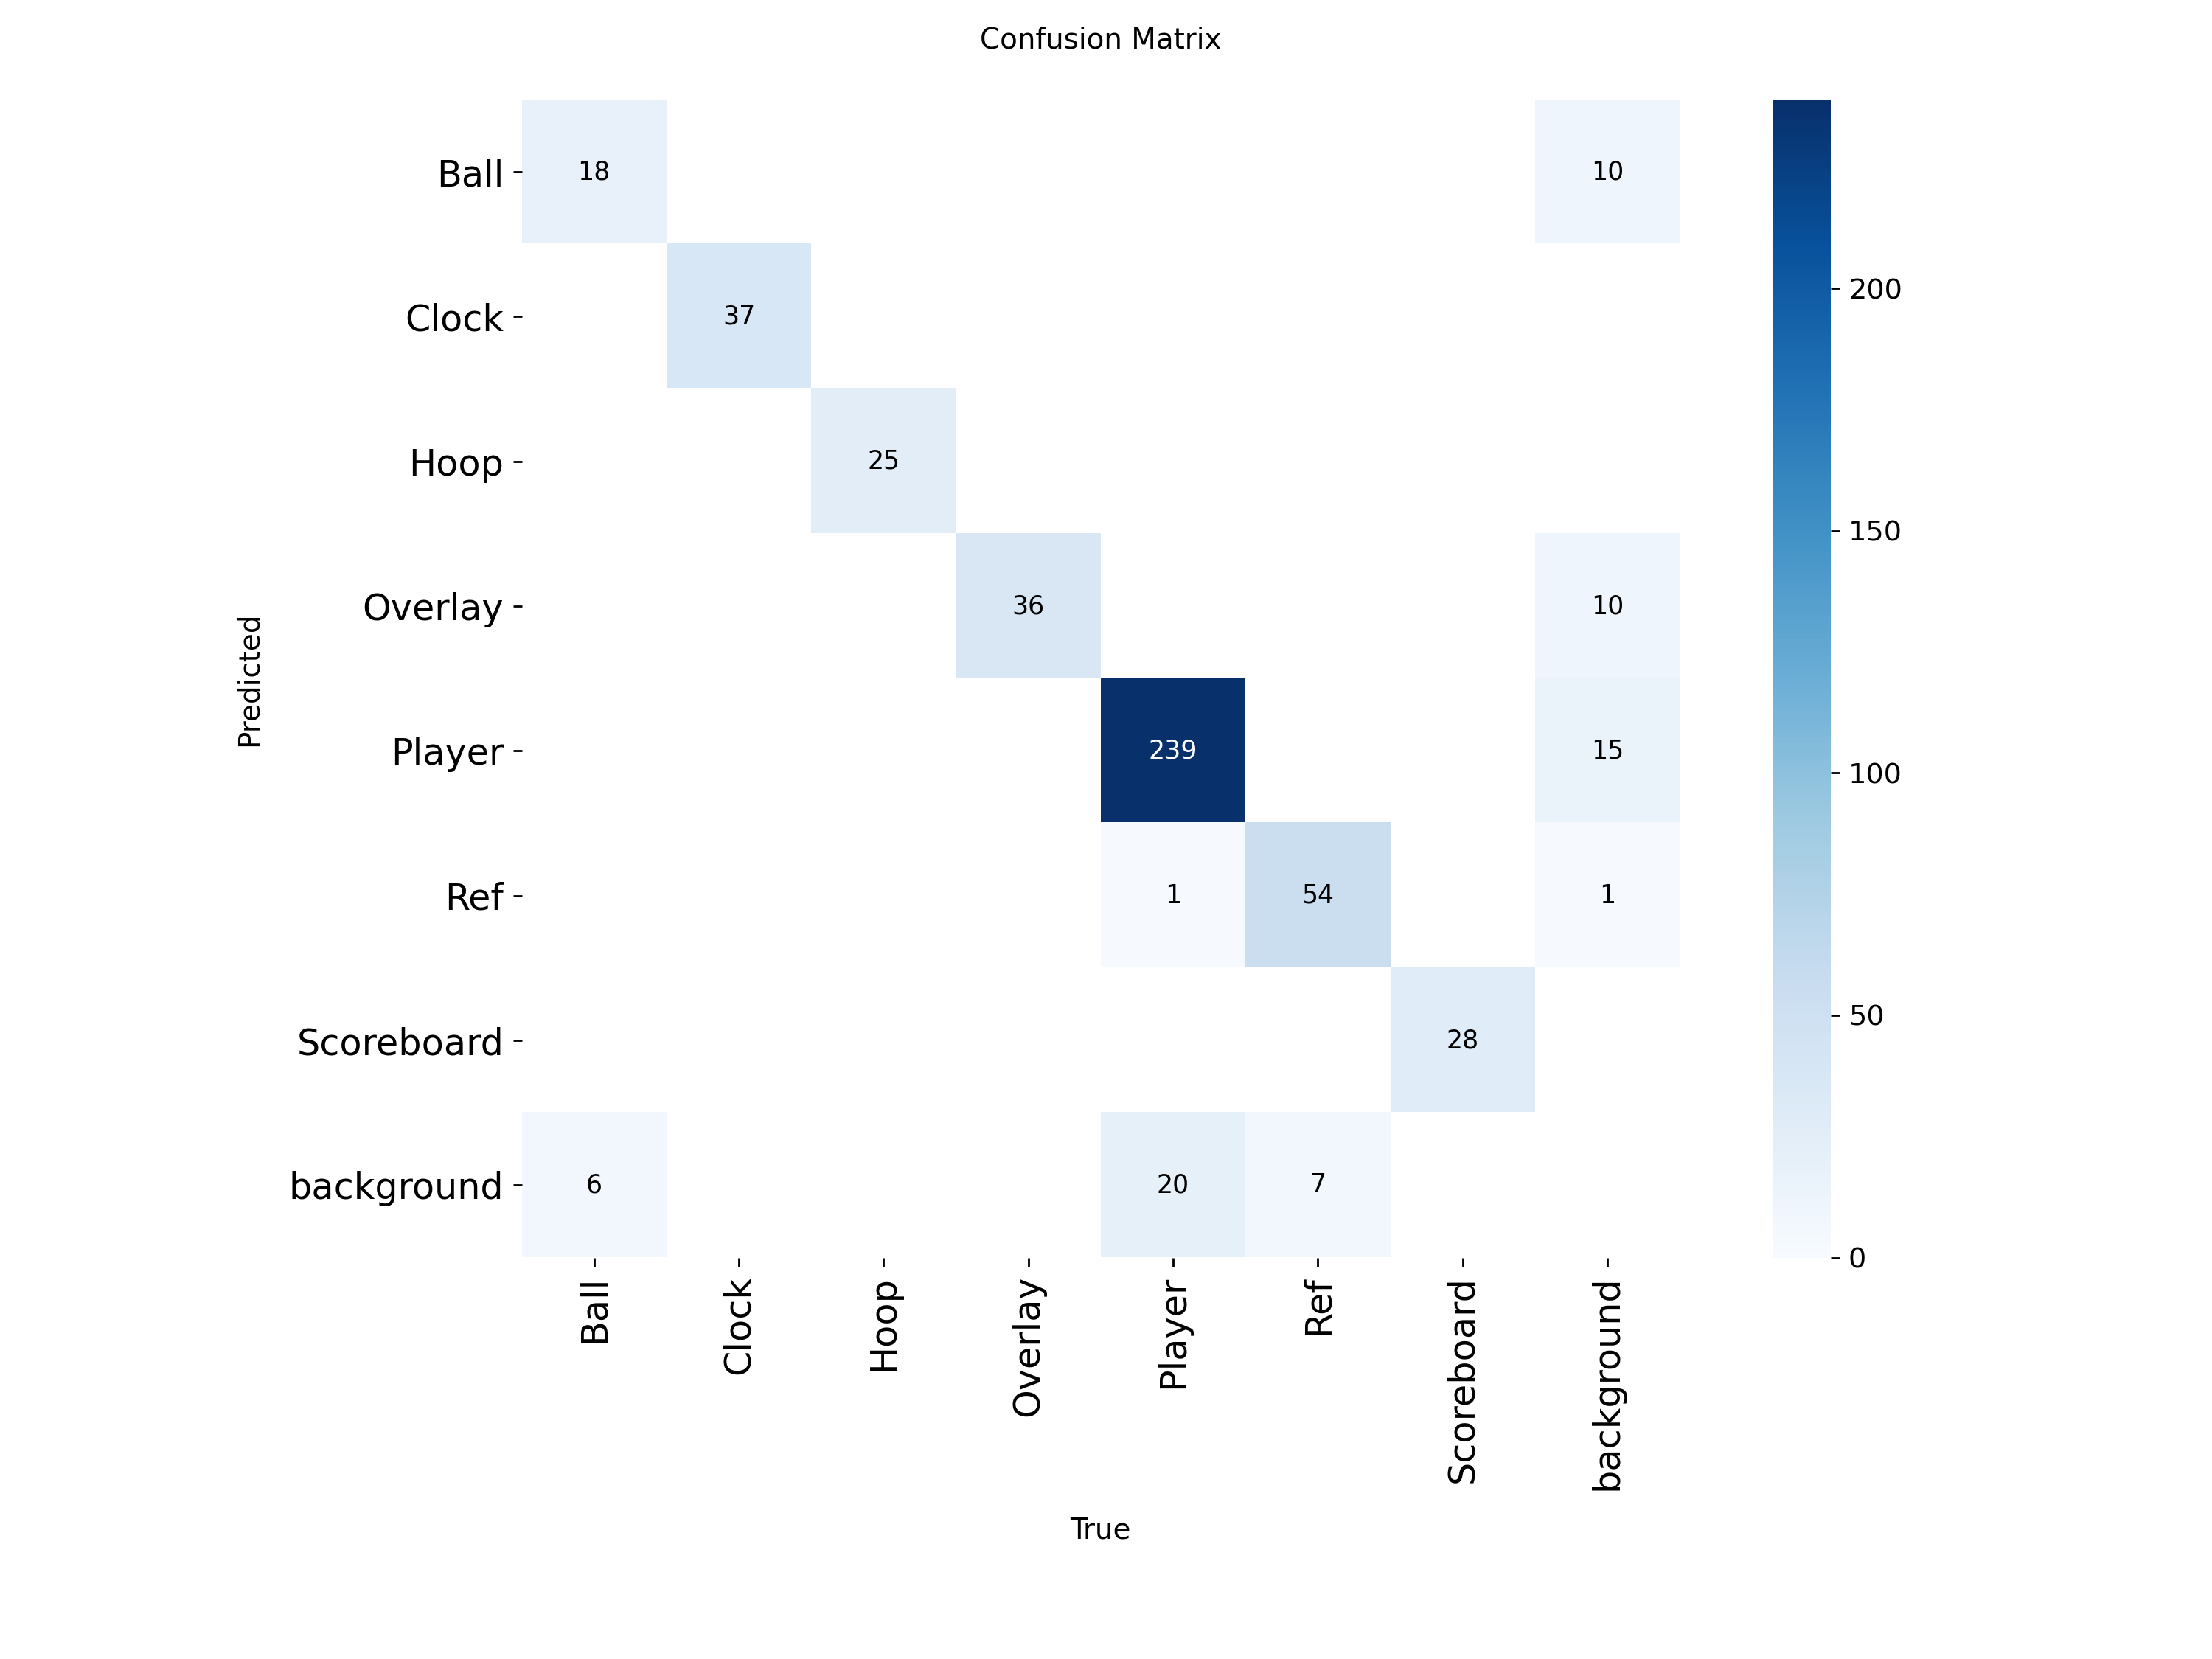

runs/detect/val2/confusion_matrix_normalized.png


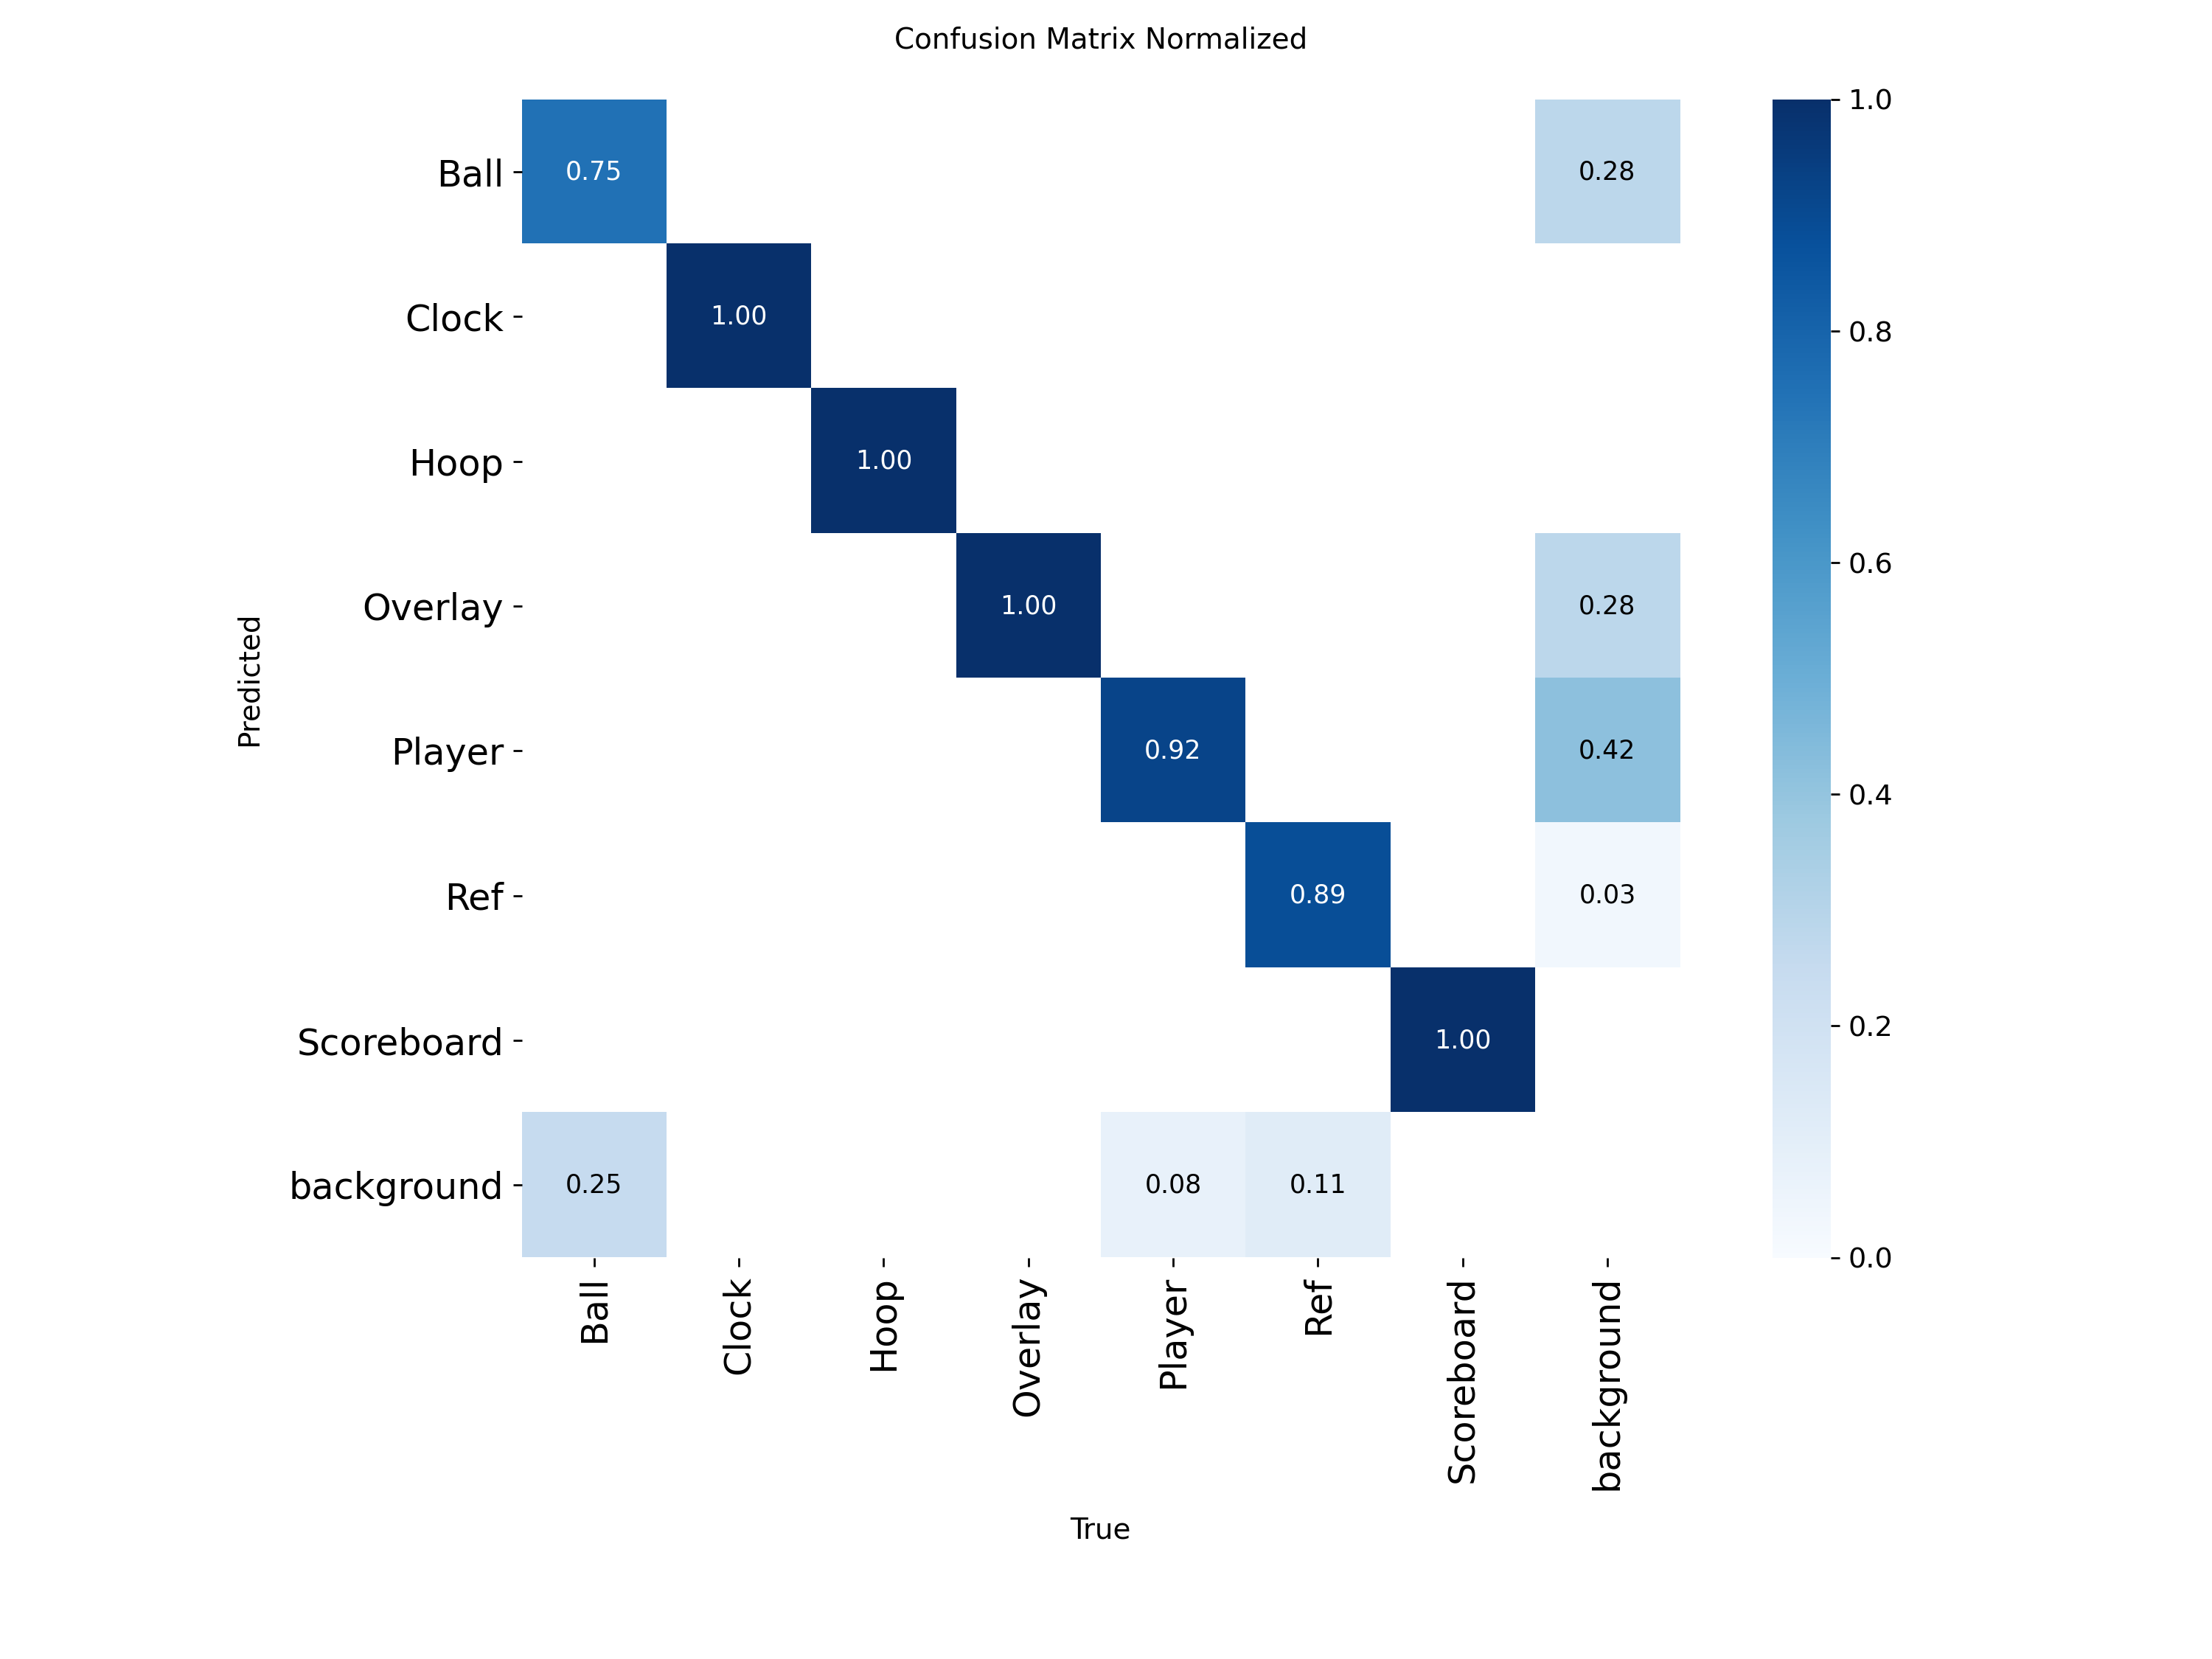

In [ ]:
from IPython.display import Image, display
import glob

for img_path in sorted(glob.glob("runs/detect/val2/*.png")):
    print(img_path)
    display(Image(filename=img_path))